In [1]:
#Import libraries
import os
import sys
sys.path.append("./scripts/")
import shutil
from brian2.units.allunits import *
from brian2.units.stdunits import *
from brian2.utils.caching import *
from scipy.sparse import coo_matrix
import numpy as np
import datalayerOmen
import random as pyrandom
import sqlalchemy as sql
import pandas as pd
from brian2 import *
from sqlalchemy import false
from sympy import true
prefs.codegen.target = "numpy"
import matplotlib.pyplot as plt
from helper import load_wmx, preprocess_monitors, generate_cue_spikes,\
                   save_vars, save_PSD, save_TFR, save_LFP, save_replay_analysis,save_wmx,save_vars_syn,SynWeightDist,save_vars_syn_cpp 
#import seaborn as sns
#from sqlalchemy import create_engine
from scipy import stats
#from plots import plot_violin, plot_raster, plot_posterior_trajectory, plot_PSD, plot_TFR, plot_zoomed, plot_detailed, plot_LFP, set_fig_dir, plot_wmx,set_len_sim,plot_histogram_wmx, plot_Zoom_Weights,fig_dir

In [2]:
engine = datalayerOmen.InitializeSQLEngine()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

def get_spike_data(expid: int,
                   engine,
                   tmin: float | None = None,
                   tmax: float | None = None,
                   hz_min: float | None = None,
                   hz_max: float | None = None,
                   hz_bin_width: float = 50.0) -> pd.DataFrame:
    """
    Query spikes for a given experiment from the SQL view.
    Adds derived 'Hz' and binned 'Hz_Bin' columns.
    """
    sql = text("""
        SELECT 
               ExpID,
               PC_ID,
               Spike_Time,
               Previous_Spike_Time,
               Spike_Time_int,
               [PC NUM],
               1000.0 / NULLIF(Spike_Time_int - Previous_Spike_Time, 0) AS Hz
        FROM [vwSpike_PC_Times - All PCs]
        WHERE ExpID = :expid
    """)
    df = pd.read_sql(sql, engine, params={"expid": expid})

    if df.empty:
        return pd.DataFrame(columns=["PC_ID", "Spike_Time", "Hz", "Hz_Bin"])

    # Basic cleanup
    df = df.dropna(subset=["PC_ID", "Spike_Time", "Hz"]).copy()

    # Apply filters
    if tmin is not None:
        df = df[df["Spike_Time"] >= tmin]
    if tmax is not None:
        df = df[df["Spike_Time"] <= tmax]
    if hz_min is not None:
        df = df[df["Hz"] >= hz_min]
    if hz_max is not None:
        df = df[df["Hz"] <= hz_max]

    # Create Hz bins (every hz_bin_width, labeled like "0–50 Hz")
    hz_bins = list(range(0, int(df["Hz"].max()) + int(hz_bin_width), int(hz_bin_width)))
    df["Hz_Bin"] = pd.cut(
        df["Hz"],
        bins=hz_bins,
        right=True,
        include_lowest=True,
        labels=[f"{low}-{low + hz_bin_width:.0f} Hz" for low in hz_bins[:-1]]
    )

    # Sort for readability
    df = df.sort_values(["PC_ID", "Spike_Time"]).reset_index(drop=True)
    return df



def plot_raster(
    df: pd.DataFrame,
    expid: int,
    use_eventplot: bool = False,
    marker_size: float = 2.0,
    alpha: float = 0.7,
    color_by_bin: bool = False,
    legend_position: str = "top",
    bbox_to_anchor: tuple | None = None,
    chart_title: str | None = None,
    xlabel: str = "Spike time",
    ylabel: str = "PC ID"
):
    """
    Plot raster from spike DataFrame (x=Spike_Time, y=PC_ID).

    Parameters
    ----------
    df : pd.DataFrame
        Data containing at least ['Spike_Time', 'PC_ID'] and optionally 'Hz_Bin'
    expid : int
        Experiment ID for labeling
    use_eventplot : bool
        Optional (currently unused, kept for extensibility)
    marker_size : float
        Size of scatter markers
    alpha : float
        Point transparency (0 = transparent, 1 = opaque)
    color_by_bin : bool
        If True, color points by Hz_Bin
    legend_position : str
        Legend placement:
          - 'top' or 'bottom' (inside full width)
          - 'outside right' or 'outside top' (legend outside plot area)
          - any valid Matplotlib keyword ('upper right', 'best', etc.)
    chart_title : str | None
        Optional chart title
    xlabel : str
        X-axis label
    ylabel : str
        Y-axis label
    """

    fig, ax = plt.subplots(figsize=(10, 6), dpi=600)

    if df.empty:
        ax.text(0.5, 0.5, f"No spikes found for ExpID={expid}",
                ha="center", va="center", fontsize=11)
        ax.set_axis_off()
        return fig, ax

    # --- Color palette ---
    color_map = {
        "0-50 Hz": "#E6E6E6",   # light gray
        "50-100 Hz": "#70BBFF", # soft blue
        "100-150 Hz": "#EC8FCA",# pink-magenta
    }
    red_shades = ["#F08080", "#FF4C4C", "#B22222"]  # for >150 Hz bins

    # --- Plot data ---
    if color_by_bin and "Hz_Bin" in df.columns:
        unique_bins = df["Hz_Bin"].unique()
        reds_used = 0

        for label in sorted(unique_bins, key=lambda x: float(str(x).split('-')[0])):
            if label in color_map:
                color = color_map[label]
            else:
                color = red_shades[min(reds_used, len(red_shades) - 1)]
                reds_used += 1

            group = df[df["Hz_Bin"] == label]
            ax.scatter(group["Spike_Time"], group["PC_ID"],
                       s=marker_size, alpha=alpha, color=color, label=label)

        # --- Legend placement logic ---
        pos = legend_position.lower()
        if pos == "top":
            legend = ax.legend(title="Firing Rate (Hz)",
                               loc="upper center",
                               bbox_to_anchor=(0.5, 1.15),
                               ncol=4,
                               frameon=False,
                               fontsize=8)
        elif pos == "bottom":
            legend = ax.legend(title="Firing Rate (Hz)",
                               loc="lower center",
                               bbox_to_anchor=(0.5, -0.25),
                               ncol=4,
                               frameon=False,
                               fontsize=8)
        elif pos == "outside right":
            legend = ax.legend(title="Firing Rate (Hz)",
                               loc="upper left",
                               bbox_to_anchor=(0.7, 1.1),
                               borderaxespad=0,
                               ncol=2,
                               frameon=True,
                               fontsize=10)
            fig.tight_layout(rect=[0, 0, 1, 1])  # make room for legend
        elif pos == "outside top":
            legend = ax.legend(title="Firing Rate (Hz)",
                               loc="lower center",
                               bbox_to_anchor=(0.5, 1.25),
                               ncol=4,
                               frameon=False,
                               fontsize=8)
            fig.tight_layout(rect=[0, 0, 1, 0.9])
        elif pos == "top left flat":
            legend = ax.legend(
                title="Firing Rate (Hz)",
                loc="upper left",
                bbox_to_anchor=(0.0, 1.15),  # slightly above axes, left-aligned
                ncol=4,                      # flat horizontal layout
                frameon=True,                # background visible (optional)
                fontsize=8
            )
            frame = legend.get_frame()
            frame.set_alpha(1.0)             # fully opaque legend
            frame.set_facecolor("white")     # solid white background (optional)
            frame.set_edgecolor("black")     # optional thin border
            fig.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for the legend
        else:
            # Direct matplotlib location (e.g., 'upper right', 'best', etc.)
            legend = ax.legend(title="Firing Rate (Hz)",
                               loc=legend_position,
                               frameon=True,
                               markerscale=3.0,
                               ncol=4,
                               fontsize=8)

    else:
        # Default single-color plot
        ax.scatter(df["Spike_Time"], df["PC_ID"],
                   s=marker_size, alpha=alpha, color="black")
        legend = None

    # --- Titles and labels ---
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(chart_title if chart_title else f"Raster plot (ExpID={expid})")

    # --- Aesthetic cleanup ---
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="both", which="both", direction="out")

    if legend_position.lower() not in ["outside right", "outside top"]:
        fig.tight_layout()

    return fig, ax

def _ensure_dir(path: str | Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    return path



def plot_pc_raster(expid: int,
                   engine,
                   tmin: float | None = None,
                   tmax: float | None = None,
                   hz_min: float | None = None,
                   hz_max: float | None = None,
                   hz_bin_width: float = 50.0,
                   outpath: str | None = None,
                   dpi: int = 600,
                   **plot_kwargs):
    """
    High-level function: retrieves spike data then delegates to plot_raster().
    """
    df = get_spike_data(expid, engine, tmin, tmax, hz_min, hz_max, hz_bin_width)
    fig, ax = plot_raster(df, expid, **plot_kwargs)
    if outpath:
        outpath = _ensure_dir(outpath)
        fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
    return fig, ax

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ---------- Helpers ----------
def _bin_low_edge(label):
    # label like "50–100 Hz" or "50-100 Hz" -> 50
    s = str(label).split(" ")[0].replace("–", "-")
    try:
        return float(s.split("-")[0])
    except Exception:
        return float("inf")

def _sorted_bins(bin_labels):
    return sorted(list(bin_labels), key=_bin_low_edge)

# ---------- Palette implementations ----------
def palette_original(bin_labels):
    """
    Original paper palette with explicit high-rate red bins.

    Explicit mapping:
      0–50    → light gray
      50–100  → soft blue
      100–150 → pink
      150–200 → bright red
      200–250 → dark red
      250+    → very dark red
    """
    base_map = {
        # low / mid
        "0–50 Hz": "#E6E6E6",
        "50–100 Hz": "#70BBFF",
        "100–150 Hz": "#EC8FCA",

        # high-rate reds (explicit)
        "150–200 Hz": "#FF4C4C",
        "200–250 Hz": "#B22222",
        "250+ Hz":   "#7A0000",

        # hyphen variants (robustness)
        "0-50 Hz": "#E6E6E6",
        "50-100 Hz": "#70BBFF",
        "100-150 Hz": "#EC8FCA",
        "150-200 Hz": "#FF4C4C",
        "200-250 Hz": "#B22222",
        "250+ Hz":   "#7A0000",
    }

    bins_sorted = _sorted_bins(bin_labels)
    cmap = {}

    for b in bins_sorted:
        key = str(b)

        # Direct match (preferred)
        if key in base_map:
            cmap[b] = base_map[key]
            continue

        # Fallback: infer by lower edge
        low = _bin_low_edge(b)
        if low < 50:
            cmap[b] = "#E6E6E6"
        elif low < 100:
            cmap[b] = "#70BBFF"
        elif low < 150:
            cmap[b] = "#EC8FCA"
        elif low < 200:
            cmap[b] = "#FF4C4C"
        elif low < 250:
            cmap[b] = "#B22222"
        else:
            cmap[b] = "#7A0000"

    return cmap

def palette_okabe_ito(bin_labels):
    """
    Colorblind-safe categorical palette (Okabe–Ito).
    Good for up to ~8 bins.
    """
    OKABE_ITO = [
        "#000000", "#E69F00", "#56B4E9",
        "#009E73", "#F0E442", "#0072B2",
        "#D55E00", "#CC79A7"
    ]
    bins_sorted = _sorted_bins(bin_labels)
    colors = [OKABE_ITO[i % len(OKABE_ITO)] for i in range(len(bins_sorted))]
    return dict(zip(bins_sorted, colors))

def palette_sequential(bin_labels, cmap_name="Reds", lo=0.35, hi=0.95):
    """
    Perceptually ordered palette from a Matplotlib colormap.
    Great when bins are ordinal (firing rate).
    lo/hi restrict extremes so the first bin isn't pure white.
    """
    bins_sorted = _sorted_bins(bin_labels)
    n = max(1, len(bins_sorted))
    cmap = cm.get_cmap(cmap_name)

    # sample evenly in [lo, hi]
    xs = np.linspace(lo, hi, n)
    colors = [cmap(x) for x in xs]
    return dict(zip(bins_sorted, colors))

def palette_grayscale(bin_labels):
    """
    Monochrome palette (very conservative / print-friendly).
    """
    bins_sorted = _sorted_bins(bin_labels)
    n = max(1, len(bins_sorted))
    xs = np.linspace(0.85, 0.15, n)  # light -> dark
    colors = [(x, x, x, 1.0) for x in xs]
    return dict(zip(bins_sorted, colors))

def palette_low_mid_high(bin_labels):
    """
    Monochrome low / mid / high palette.

    Maps firing-rate bins into:
      - low  → light gray
      - mid  → medium gray
      - high → dark gray

    Intended for very conservative, print-friendly figures.
    """
    palette = {
        "low": "#D9D9D9",
        "mid": "#7F7F7F",
        "high": "#252525",
    }

    bins_sorted = _sorted_bins(bin_labels)
    n = len(bins_sorted)

    if n == 0:
        return {}

    # Split bins into thirds (low / mid / high)
    colors = {}
    for i, b in enumerate(bins_sorted):
        frac = i / max(1, n - 1)
        if frac < 1/3:
            colors[b] = palette["low"]
        elif frac < 2/3:
            colors[b] = palette["mid"]
        else:
            colors[b] = palette["high"]

    return colors

# ---------- Choose ONE active palette here ----------
# ACTIVE_PALETTE = "low_mid_high"
ACTIVE_PALETTE = "original"
# ACTIVE_PALETTE = "okabe_ito"
# ACTIVE_PALETTE = "seq_reds"
# ACTIVE_PALETTE = "seq_blues"
#ACTIVE_PALETTE = "grayscale"

def get_palette(bin_labels):
    if ACTIVE_PALETTE == "original":
        return palette_original(bin_labels)
    if ACTIVE_PALETTE == "low_mid_high":
        return palette_low_mid_high(bin_labels)
    if ACTIVE_PALETTE == "okabe_ito":
        return palette_okabe_ito(bin_labels)
    if ACTIVE_PALETTE == "seq_reds":
        return palette_sequential(bin_labels, cmap_name="Reds")
    if ACTIVE_PALETTE == "seq_blues":
        return palette_sequential(bin_labels, cmap_name="Blues")
    if ACTIVE_PALETTE == "grayscale":
        return palette_grayscale(bin_labels)

    raise ValueError(f"Unknown ACTIVE_PALETTE: {ACTIVE_PALETTE}")

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.ticker import MaxNLocator
from sqlalchemy import text
from pathlib import Path

# ---------- Style (paper-friendly defaults) ----------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.size": 6.0,
    "axes.titlesize": 6.0,
    "axes.labelsize": 6.0,
    "xtick.labelsize": 6.0,
    "ytick.labelsize": 6.0,
    "legend.fontsize": 6.0,
    "legend.title_fontsize": 6.0,
    "legend.markerscale": 3.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def _ensure_dir(path: str | Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    return path

# ---------- Data ----------
def get_spike_data(
    expid: int,
    engine,
    tmin: float | None = None,
    tmax: float | None = None,
    hz_min: float | None = None,
    hz_max: float | None = None,
    hz_bin_width: float = 50.0
) -> pd.DataFrame:
    """
    Query spikes for a given experiment from the SQL view.
    Adds derived 'Hz' and binned 'Hz_Bin' columns.

    Notes:
    - Hz is computed as 1000 / ISI using Spike_Time_int and Previous_Spike_Time.
    - If the first spike has no previous time, Hz becomes NaN and is dropped below.
    """
    sql = text("""
        SELECT 
               ExpID,
               PC_ID,
               Spike_Time,
               Previous_Spike_Time,
               Spike_Time_int,
               [PC NUM],
               1000.0 / NULLIF(Spike_Time_int - Previous_Spike_Time, 0) AS Hz
        FROM [vwSpike_PC_Times - All PCs]
        WHERE ExpID = :expid
    """)
    df = pd.read_sql(sql, engine, params={"expid": expid})

    if df.empty:
        return pd.DataFrame(columns=["PC_ID", "Spike_Time", "Hz", "Hz_Bin"])

    # Basic cleanup
    df = df.dropna(subset=["PC_ID", "Spike_Time"]).copy()

    # Hz can be NaN for first spike per neuron; keep it for raster, but Hz-binning will ignore NaNs.
    # (We won't drop NaN Hz unless user is explicitly filtering by Hz.)
    if hz_min is not None or hz_max is not None:
        df = df.dropna(subset=["Hz"]).copy()

    # Apply filters
    if tmin is not None:
        df = df[df["Spike_Time"] >= tmin]
    if tmax is not None:
        df = df[df["Spike_Time"] <= tmax]
    if hz_min is not None:
        df = df[df["Hz"] >= hz_min]
    if hz_max is not None:
        df = df[df["Hz"] <= hz_max]

    # Sort for readability
    df = df.sort_values(["PC_ID", "Spike_Time"]).reset_index(drop=True)

    # Create Hz bins only if Hz exists
    if "Hz" in df.columns and df["Hz"].notna().any() and hz_bin_width and hz_bin_width > 0:
        hz_max_val = float(np.nanmax(df["Hz"].values))
        # Make bins: [0, w, 2w, ... >= max]
        edges = np.arange(0.0, hz_max_val + hz_bin_width, hz_bin_width)
        if len(edges) < 2:
            edges = np.array([0.0, hz_bin_width])

        labels = [f"{int(edges[i])}–{int(edges[i+1])} Hz" for i in range(len(edges) - 1)]
        df["Hz_Bin"] = pd.cut(
            df["Hz"],
            bins=edges,
            right=True,
            include_lowest=True,
            labels=labels
        )
    else:
        df["Hz_Bin"] = pd.Series([pd.NA] * len(df))

    return df

def rate_bin_color_map(bin_labels):
    """
    Assign colors to firing-rate bins using the original paper palette logic.
    bin_labels: iterable of bin labels like '0–50 Hz'
    """
    # Base colors from your original code
    base_map = {
        "0–50 Hz": "#E6E6E6",    # light gray
        "50–100 Hz": "#70BBFF",  # soft blue
        "100–150 Hz": "#EC8FCA", # magenta/pink
    }

    red_shades = ["#F08080", "#FF4C4C", "#B22222"]  # higher-rate emphasis

    colors = {}
    reds_used = 0

    # Sort numerically by lower bound
    def low_edge(label):
        return float(str(label).split(" ")[0].replace("–", "-").split("-")[0])

    for label in sorted(bin_labels, key=low_edge):
        if label in base_map:
            colors[label] = base_map[label]
        else:
            colors[label] = red_shades[min(reds_used, len(red_shades) - 1)]
            reds_used += 1

    return colors

# ---------- Plot helpers ----------
def _bin_order_key(label):
    # label like "50–100 Hz" -> 50
    if pd.isna(label):
        return float("inf")
    s = str(label).split(" ")[0].replace("–", "-")
    try:
        return float(s.split("-")[0])
    except Exception:
        return float("inf")

def _default_bin_colors(n_bins: int):
    """
    Produce a readable discrete palette without seaborn.
    Uses Matplotlib's tab10/tab20 depending on size.
    """
    cmap = plt.get_cmap("tab10" if n_bins <= 10 else "tab20")
    return [cmap(i) for i in range(n_bins)]

def plot_raster_professional(
    df: pd.DataFrame,
    expid: int,
    *,
    chart_title: str | None = None,
    xlabel: str = "Time (ms)",
    ylabel: str = "PC ID",
    marker_size: float = 0.8,
    alpha: float = 0.8,
    color_by_bin: bool = False,
    legend: bool = True,
    legend_position: str = "outside_right",   # "top", "bottom", "outside_right", "none"
    max_legend_bins: int = 10,                # limit legend entries for readability
    y_tick_step: int | None = None,           # e.g., 500 for 0..8000 PCs
    figsize=(3.2, 2.0),
    rasterized: bool = True,                  # makes PDFs smaller with huge scatter
    y_col: str = "PC_ID",
    outpath: str | None = None, 
                  
    legend_loc: str | None = None,                   # if set, overrides legend_position mapping
    legend_bbox_to_anchor: tuple[float, float] | None = None,
    legend_ncol: int | None = None,
    legend_title: str = "Firing rate (Hz, binned)",
    legend_fontsize: float | None = None,
    legend_title_fontsize: float | None = None,
    legend_markerscale: float | None = None,
    legend_frameon: bool | None = None,
    legend_framealpha: float | None = None,              # e.g. "figs/raster_1234.pdf"
    dpi: int = 600
):
    """
    Publication-ready raster plot.

    - Fast, clean scatter with optional Hz-bin coloring.
    - Legend can be placed outside to preserve data area.
    - rasterized=True keeps vector PDFs small for large N.
    """
    fig, ax = plt.subplots(figsize=figsize)

    if df.empty:
        ax.text(0.5, 0.5, f"No spikes found for ExpID={expid}",
                ha="center", va="center")
        ax.set_axis_off()
        return fig, ax

    # Basic bounds for nice padding
    x = df["Spike_Time"].to_numpy()
    y = df[y_col].to_numpy()

    # --- Plot ---
    if color_by_bin and "Hz_Bin" in df.columns and df["Hz_Bin"].notna().any():
        # Order bins numerically
        bins_sorted = sorted(df["Hz_Bin"].dropna().unique(), key=_bin_low_edge)
        color_map = get_palette(bins_sorted)

        for b in bins_sorted:
            g = df[df["Hz_Bin"] == b]
            ax.scatter(
                g["Spike_Time"], g[y_col],
                s=marker_size,
                alpha=alpha,
                linewidths=0,
                color=color_map[b],
                label=str(b),
                rasterized=True
            )
        bins_for_legend = bins_sorted[:max_legend_bins]

        # Legend handling
        if legend and len(bins_for_legend) > 0 and legend_position.lower() not in ("none", "off"):

            pos = legend_position.lower()

            # Friendly aliases -> (loc, bbox_to_anchor, outside_adjust)
            alias_map = {
                "top":          ("lower center", (0.5, 1.02), None),
                "bottom":       ("upper center", (0.5, -0.18), None),
                "outside_right":("upper left",   (1.02, 1.0),  0.78),
                "outside_top":  ("lower center", (0.5, 1.20), None),
                # Your preferred compact overlapping legend:
                "top_right":    ("upper right",  None,        None),
                "top_left":     ("upper left",   None,        None),
                "bottom_right": ("lower right",  None,        None),
                "bottom_left":  ("lower left",   None,        None),
            }

            # Determine loc + bbox_to_anchor:
            # 1) explicit legend_loc overrides everything
            # 2) else, use alias_map if matches
            # 3) else, treat legend_position as a raw matplotlib loc string
            if legend_loc is not None:
                loc = legend_loc
                bbox = legend_bbox_to_anchor
                right_adjust = None
            elif pos in alias_map:
                loc, bbox, right_adjust = alias_map[pos]
                # Allow explicit bbox override to "nudge" any alias
                if legend_bbox_to_anchor is not None:
                    bbox = legend_bbox_to_anchor
            else:
                loc = legend_position  # raw matplotlib loc like "upper right"
                bbox = legend_bbox_to_anchor
                right_adjust = None

            # ncol default: wide for top/bottom/outside_top, otherwise compact
            if legend_ncol is None:
                if pos in ("top", "bottom", "outside_top"):
                    ncol = min(5, len(bins_for_legend))
                else:
                    ncol = 1
            else:
                ncol = legend_ncol

            # Call legend with sensible defaults, but allow overrides
            lgd = ax.legend(
                title=legend_title,
                loc=loc,
                bbox_to_anchor=bbox,
                ncol=ncol,
                frameon=(False if legend_frameon is None else legend_frameon),
                fontsize=legend_fontsize,
                title_fontsize=legend_title_fontsize,
                markerscale=legend_markerscale,
                borderaxespad=0.0 if pos == "outside_right" else None,
                handletextpad=0.3,
                columnspacing=0.9,
                labelspacing=0.3,
                borderpad=0.4,
                handlelength=1.2
            )

            # Optional transparency if frame is on
            if lgd is not None and legend_framealpha is not None:
                lgd.get_frame().set_alpha(legend_framealpha)
                lgd.get_frame().set_linewidth(0.6)

            # If outside-right, make room
            if right_adjust is not None:
                fig.subplots_adjust(right=right_adjust)

            # If bins were truncated, add a note
            if len(bins_sorted) > max_legend_bins:
                ax.text(
                    0.01, 0.01,
                    f"Legend shows first {max_legend_bins} bins (of {len(bins_sorted)}).",
                    transform=ax.transAxes,
                    fontsize=8,
                    va="bottom", ha="left",
                    alpha=0.8
                )

    else:
        ax.scatter(
            x, y,
            s=marker_size, alpha=alpha, linewidths=0,
            color="black",
            rasterized=rasterized
        )

    # --- Labels & title ---
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(chart_title if chart_title else f"Raster plot (ExpID={expid})")

    # --- Ticks / grid (subtle) ---
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    if y_tick_step is not None and y_tick_step > 0:
        ymin, ymax = np.nanmin(y), np.nanmax(y)
        yticks = np.arange((ymin // y_tick_step) * y_tick_step, ymax + y_tick_step, y_tick_step)
        ax.set_yticks(yticks)
    else:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    ax.grid(False)
    ax.tick_params(direction="out", length=3, width=0.8)

    fig.tight_layout()

    if outpath:
        outpath = _ensure_dir(outpath)
        fig.savefig(outpath, dpi=dpi, bbox_inches="tight")

    return fig, ax

# ---------- Convenience wrapper ----------
def plot_pc_raster_professional(
    expid: int,
    engine,
    tmin: float | None = None,
    tmax: float | None = None,
    hz_min: float | None = None,
    hz_max: float | None = None,
    hz_bin_width: float = 50.0,
    use_pc_order: bool = False,
    **plot_kwargs
):
    df = get_spike_data(expid, engine, tmin, tmax, hz_min, hz_max, hz_bin_width)
    if use_pc_order:
        order_sql = text("""
            SELECT PC_Index, PC_Order
            FROM place_field_selected
            WHERE ExpID = :expid
        """)
        order_df = pd.read_sql(order_sql, engine, params={"expid": expid})
        df = df.merge(order_df[["PC_Index", "PC_Order"]], left_on="PC_ID", right_on="PC_Index", how="left")
        plot_kwargs.setdefault("y_col", "PC_Order")
        plot_kwargs.setdefault("ylabel", "Place Field Order")
    fig, ax = plot_raster_professional(df, expid, **plot_kwargs)
    return fig, ax

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sqlalchemy import text
from pathlib import Path

# ---------- Style (paper-friendly defaults) ----------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.size": 6.0,
    "axes.titlesize": 6.0,
    "axes.labelsize": 6.0,
    "xtick.labelsize": 6.0,
    "ytick.labelsize": 6.0,
    "legend.fontsize": 6.0,
    "legend.title_fontsize": 6.0,
    "legend.markerscale": 3.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def _ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


# ---------- Data ----------
def get_spike_data(
    expid: int,
    engine,
    tmin: float | None = None,
    tmax: float | None = None,
    hz_min: float | None = None,
    hz_max: float | None = None,
    hz_bin_width: float = 50.0
) -> pd.DataFrame:
    """
    Query spikes for a given experiment from the SQL view.
    Adds derived 'Hz' and binned 'Hz_Bin' columns.

    Notes:
    - Hz is computed as 1000 / ISI using Spike_Time_int and Previous_Spike_Time.
    - If the first spike has no previous time, Hz becomes NaN.
    """
    sql = text("""
        SELECT 
               ExpID,
               PC_ID,
               Spike_Time,
               Previous_Spike_Time,
               Spike_Time_int,
               --[PC NUM],
               1000.0 / NULLIF(Spike_Time_int - Previous_Spike_Time, 0) AS Hz
        FROM [vwSpike_PC_Times - All PCs]
        WHERE ExpID = :expid
    """)
    df = pd.read_sql(sql, engine, params={"expid": expid})

    if df.empty:
        return pd.DataFrame(columns=["PC_ID", "Spike_Time", "Hz", "Hz_Bin"])

    df = df.dropna(subset=["PC_ID", "Spike_Time"]).copy()

    # If user filters by Hz, drop NaN Hz; otherwise keep NaN Hz (raster can still plot)
    if hz_min is not None or hz_max is not None:
        df = df.dropna(subset=["Hz"]).copy()

    if tmin is not None:
        df = df[df["Spike_Time"] >= tmin]
    if tmax is not None:
        df = df[df["Spike_Time"] <= tmax]
    if hz_min is not None:
        df = df[df["Hz"] >= hz_min]
    if hz_max is not None:
        df = df[df["Hz"] <= hz_max]

    df = df.sort_values(["PC_ID", "Spike_Time"]).reset_index(drop=True)

    # Create Hz bins if we have any finite Hz values
    if hz_bin_width and hz_bin_width > 0 and "Hz" in df.columns and df["Hz"].notna().any():
        hz_max_val = float(np.nanmax(df["Hz"].values))
        edges = np.arange(0.0, hz_max_val + hz_bin_width, hz_bin_width)
        if len(edges) < 2:
            edges = np.array([0.0, hz_bin_width])

        # IMPORTANT: use en-dash ‘–’ to match your palette map keys
        labels = [f"{int(edges[i])}–{int(edges[i+1])} Hz" for i in range(len(edges) - 1)]
        df["Hz_Bin"] = pd.cut(
            df["Hz"],
            bins=edges,
            right=True,
            include_lowest=True,
            labels=labels
        )
    else:
        df["Hz_Bin"] = pd.Series([pd.NA] * len(df))

    return df


# ---------- Palette ----------
def _bin_low_edge(label) -> float:
    """
    Extract lower edge from labels like '50–100 Hz'
    """
    if pd.isna(label):
        return float("inf")
    s = str(label).split(" ")[0].replace("–", "-")  # '50-100'
    try:
        return float(s.split("-")[0])
    except Exception:
        return float("inf")


def rate_bin_color_map(bin_labels):
    """
    Assign colors to firing-rate bins using your original palette logic:
    base bins up to 150 Hz then reds for the rest.
    """
    base_map = {
        "0–50 Hz": "#E6E6E6",     # light gray
        "50–100 Hz": "#70BBFF",   # soft blue
        "100–150 Hz": "#EC8FCA",  # pink-magenta
    }
    red_shades = ["#F08080", "#FF4C4C", "#B22222"]  # higher-rate emphasis

    colors = {}
    reds_used = 0

    for label in sorted(bin_labels, key=_bin_low_edge):
        key = str(label)
        if key in base_map:
            colors[label] = base_map[key]
        else:
            colors[label] = red_shades[min(reds_used, len(red_shades) - 1)]
            reds_used += 1

    return colors


def get_palette(bins_sorted):
    """
    Central hook: right now uses your original palette.
    If you want to add other palettes later, swap here.
    """
    return rate_bin_color_map(bins_sorted)


# ---------- Plot ----------
def plot_raster_professional(
    df: pd.DataFrame,
    expid: int,
    *,
    chart_title: str | None = None,
    xlabel: str = "Time (ms)",
    ylabel: str = "PC ID",
    marker_size: float = 0.8,
    alpha: float = 0.8,
    color_by_bin: bool = False,
    legend: bool = True,
    legend_position: str = "outside_right",
    max_legend_bins: int = 10,
    y_tick_step: int | None = None,
    figsize=(6.8, 4.2),
    rasterized: bool = True,
    y_col: str = "PC_ID",
    outpath: str | None = None,

    # Legend fine control (optional overrides)
    legend_loc: str | None = None,
    legend_bbox_to_anchor: tuple[float, float] | None = None,
    legend_ncol: int | None = None,
    legend_title: str = "Firing rate (Hz, binned)",
    legend_fontsize: float | None = None,
    legend_title_fontsize: float | None = None,
    legend_markerscale: float | None = None,
    legend_frameon: bool | None = None,
    legend_framealpha: float | None = None,
    dpi: int = 600
):
    fig, ax = plt.subplots(figsize=figsize)

    if df.empty:
        ax.text(0.5, 0.5, f"No spikes found for ExpID={expid}",
                ha="center", va="center")
        ax.set_axis_off()
        return fig, ax

    x = df["Spike_Time"].to_numpy()
    y = df[y_col].to_numpy()

    if color_by_bin and "Hz_Bin" in df.columns and df["Hz_Bin"].notna().any():
        bins_sorted = sorted(df["Hz_Bin"].dropna().unique(), key=_bin_low_edge)
        color_map = get_palette(bins_sorted)

        for b in bins_sorted:
            g = df[df["Hz_Bin"] == b]
            ax.scatter(
                g["Spike_Time"], g[y_col],
                s=marker_size,
                alpha=alpha,
                linewidths=0,
                color=color_map[b],
                label=str(b),
                rasterized=rasterized
            )

        bins_for_legend = bins_sorted[:max_legend_bins]

        if legend and len(bins_for_legend) > 0 and legend_position.lower() not in ("none", "off"):
            pos = legend_position.lower()

            alias_map = {
                "top":           ("lower center", (0.5, 1.02), None),
                "bottom":        ("upper center", (0.5, -0.18), None),
                "outside_right": ("upper left",   (1.02, 1.0),  0.78),
                "outside_top":   ("lower center", (0.5, 1.20), None),
                "top_right":     ("upper right",  None,        None),
                "top_left":      ("upper left",   None,        None),
                "bottom_right":  ("lower right",  None,        None),
                "bottom_left":   ("lower left",   None,        None),
            }

            if legend_loc is not None:
                loc = legend_loc
                bbox = legend_bbox_to_anchor
                right_adjust = None
            elif pos in alias_map:
                loc, bbox, right_adjust = alias_map[pos]
                if legend_bbox_to_anchor is not None:
                    bbox = legend_bbox_to_anchor
            else:
                loc = legend_position
                bbox = legend_bbox_to_anchor
                right_adjust = None

            if legend_ncol is None:
                if pos in ("top", "bottom", "outside_top"):
                    ncol = min(5, len(bins_for_legend))
                else:
                    ncol = 1
            else:
                ncol = legend_ncol

            lgd = ax.legend(
                title=legend_title,
                loc=loc,
                bbox_to_anchor=bbox,
                ncol=ncol,
                frameon=(True if legend_frameon is None else legend_frameon),
                fontsize=(legend_fontsize if legend_fontsize is not None else plt.rcParams["legend.fontsize"]),
                title_fontsize=(legend_title_fontsize if legend_title_fontsize is not None else plt.rcParams["legend.title_fontsize"]),
                markerscale=(legend_markerscale if legend_markerscale is not None else plt.rcParams["legend.markerscale"]),
                borderaxespad=0.0 if pos == "outside_right" else None,
                handletextpad=0.3,
                columnspacing=0.9,
                labelspacing=0.3,
                borderpad=0.4,
                handlelength=1.2
            )

            if lgd is not None and legend_framealpha is not None:
                lgd.get_frame().set_alpha(legend_framealpha)
                lgd.get_frame().set_linewidth(0.6)

            if right_adjust is not None:
                fig.subplots_adjust(right=right_adjust)

            if len(bins_sorted) > max_legend_bins:
                ax.text(
                    0.01, 0.01,
                    f"Legend shows first {max_legend_bins} bins (of {len(bins_sorted)}).",
                    transform=ax.transAxes,
                    fontsize=8,
                    va="bottom", ha="left",
                    alpha=0.8
                )

    else:
        ax.scatter(
            x, y,
            s=marker_size,
            alpha=alpha,
            linewidths=0,
            color="black",
            rasterized=rasterized
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(chart_title if chart_title else None)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    if y_tick_step is not None and y_tick_step > 0:
        ymin, ymax = np.nanmin(y), np.nanmax(y)
        yticks = np.arange((ymin // y_tick_step) * y_tick_step, ymax + y_tick_step, y_tick_step)
        ax.set_yticks(yticks)
    else:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    ax.grid(False)
    ax.tick_params(direction="out", length=3, width=0.8)

    fig.tight_layout()

    if outpath:
        outpath = _ensure_dir(outpath)
        fig.savefig(outpath, dpi=dpi, bbox_inches="tight")

    return fig, ax


# ---------- Convenience wrapper ----------
def plot_pc_raster_professional(
    expid: int,
    engine,
    tmin: float | None = None,
    tmax: float | None = None,
    hz_min: float | None = None,
    hz_max: float | None = None,
    hz_bin_width: float = 50.0,
    use_pc_order: bool = False,
    **plot_kwargs
):
    df = get_spike_data(expid, engine, tmin, tmax, hz_min, hz_max, hz_bin_width)
    if use_pc_order:
        order_sql = text("""
            SELECT PC_Index, PC_Order
            FROM place_field_selected
            WHERE ExpID = :expid
        """)
        order_df = pd.read_sql(order_sql, engine, params={"expid": expid})
        df = df.merge(order_df[["PC_Index", "PC_Order"]], left_on="PC_ID", right_on="PC_Index", how="left")
        plot_kwargs.setdefault("y_col", "PC_Order")
        plot_kwargs.setdefault("ylabel", "Place Field Order")
    fig, ax = plot_raster_professional(df, expid, **plot_kwargs)
    return fig, ax

In [15]:
# --- Imports (single place, notebook-friendly) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from pathlib import Path
from matplotlib.ticker import MaxNLocator


# ---------------------------
# Utilities
# ---------------------------
def _ensure_dir(path: str | Path) -> Path:
    """Ensure parent directory exists; return Path."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def _low_edge(label) -> float:
    """
    Extract the lower edge from labels like:
      '150-200 Hz', '250+ Hz', '150–200 Hz'
    """
    s = str(label).strip().replace("–", "-")
    first = s.split()[0]  # e.g. "150-200" or "250+"
    try:
        if first.endswith("+"):
            return float(first[:-1])
        return float(first.split("-")[0])
    except Exception:
        return float("inf")


def _set_xticks_end_at_max(ax, xmin: float, xmax: float, nbins: int = 6):
    """
    Make x-axis ticks *include* the last x value (xmax) exactly.
    Uses a MaxNLocator-like spacing, but forces the final tick to equal xmax.
    """
    locator = MaxNLocator(nbins=nbins)
    ticks = locator.tick_values(xmin, xmax)

    # Keep ticks within range
    ticks = ticks[(ticks >= xmin) & (ticks <= xmax)]
    ticks = np.unique(np.round(ticks, 10))

    # Ensure xmax is included as a tick
    if len(ticks) == 0:
        ticks = np.array([xmin, xmax], dtype=float)
    else:
        # If last tick is very close but not equal, replace it; otherwise append
        if not np.isclose(ticks[-1], xmax):
            # If xmax is beyond last tick, append. If last tick beyond xmax, replace.
            if ticks[-1] < xmax:
                ticks = np.append(ticks, xmax)
            else:
                ticks[-1] = xmax
        else:
            ticks[-1] = xmax

        # Also ensure xmin is included (nice symmetry)
        if not np.isclose(ticks[0], xmin):
            if ticks[0] > xmin:
                ticks = np.insert(ticks, 0, xmin)
            else:
                ticks[0] = xmin

    ax.set_xticks(ticks)


# ---------------------------
# Data extraction
# ---------------------------
def get_spike_data(
    expid: int,
    engine,
    tmin: float | None = None,
    tmax: float | None = None,
    hz_min: float | None = None,
    hz_max: float | None = None,
    hz_bin_width: float = 50.0,
) -> pd.DataFrame:
    """
    Query spikes for a given experiment from the SQL view.
    Adds derived 'Hz' and binned 'Hz_Bin' columns.
    """
    sql = text("""
        SELECT 
               ExpID,
               PC_ID,
               Spike_Time,
               Previous_Spike_Time,
               Spike_Time_int,
               --[PC NUM],
               1000.0 / NULLIF(Spike_Time_int - Previous_Spike_Time, 0) AS Hz
        FROM [vwSpike_PC_Times - All PCs]
        WHERE ExpID = :expid
    """)

    df = pd.read_sql(sql, engine, params={"expid": expid})

    if df.empty:
        return pd.DataFrame(columns=["PC_ID", "Spike_Time", "Hz", "Hz_Bin"])

    # Basic cleanup
    # NOTE: your original code dropped NaN Hz. Keeping that behavior.
    df = df.dropna(subset=["PC_ID", "Spike_Time", "Hz"]).copy()

    # Filters
    if tmin is not None:
        df = df[df["Spike_Time"] >= tmin]
    if tmax is not None:
        df = df[df["Spike_Time"] <= tmax]
    if hz_min is not None:
        df = df[df["Hz"] >= hz_min]
    if hz_max is not None:
        df = df[df["Hz"] <= hz_max]

    if df.empty:
        return pd.DataFrame(columns=["PC_ID", "Spike_Time", "Hz", "Hz_Bin"])

    # Sort
    df = df.sort_values(["PC_ID", "Spike_Time"]).reset_index(drop=True)

    # Hz bins: fixed width with explicit final "X+ Hz" bin
    step = float(hz_bin_width)
    max_hz = float(df["Hz"].max())

    edges = np.arange(0.0, max_hz + step, step)
    if len(edges) < 2:
        edges = np.array([0.0, step])

    edges = np.append(edges, np.inf)  # open-ended last bin

    labels = [f"{int(edges[i])}-{int(edges[i+1])} Hz" for i in range(len(edges) - 2)]
    labels.append(f"{int(edges[-2])}+ Hz")

    df["Hz_Bin"] = pd.cut(
        df["Hz"],
        bins=edges,
        right=True,
        include_lowest=True,
        labels=labels
    )

    return df


# ---------------------------
# Plotting
# ---------------------------
def plot_raster(
    df: pd.DataFrame,
    expid: int,
    marker_size: float = 2.0,
    alpha: float = 0.7,
    color_by_bin: bool = False,
    legend_position: str = "top",
    bbox_to_anchor: tuple[float, float] | None = None,
    chart_title: str | None = None,
    xlabel: str = "Spike time",
    ylabel: str = "PC ID",
    tmax: float | None = None,          # <<< NEW
    force_last_xtick: bool = True,
    xtick_nbins: int = 6,
    rasterized: bool = True,
):
    """
    Plot raster from spike DataFrame (x=Spike_Time, y=PC_ID).
    - Deterministic color mapping, including explicit 150–200, 200–250, 250+ reds.
    - bbox_to_anchor is supported for fine legend placement nudges.
    - Can force the final x tick to be exactly the last x value shown.
    """

    fig, ax = plt.subplots(figsize=(10, 6))  # DPI controlled at savefig

    if df.empty:
        ax.text(0.5, 0.5, f"No spikes found for ExpID={expid}",
                ha="center", va="center", fontsize=11)
        ax.set_axis_off()
        return fig, ax

    # ---- Palette (explicit, deterministic) ----
    color_map = {
        "0-50 Hz":   "#E6E6E6",  # light gray
        "50-100 Hz": "#70BBFF",  # soft blue
        "100-150 Hz":"#EC8FCA",  # pink-magenta
        "150-200 Hz":"#FF4C4C",  # red
        "200-250 Hz":"#B22222",  # dark red
        "250+ Hz":   "#7A0000",  # very dark red
    }

    # ---- Plot ----
    if color_by_bin and "Hz_Bin" in df.columns and df["Hz_Bin"].notna().any():
        unique_bins = df["Hz_Bin"].dropna().unique()

        for label in sorted(unique_bins, key=_low_edge):
            key = str(label)
            # If bins are wider/different, fall back based on lower edge:
            if key not in color_map:
                low = _low_edge(label)
                if low < 50:
                    color = color_map["0-50 Hz"]
                elif low < 100:
                    color = color_map["50-100 Hz"]
                elif low < 150:
                    color = color_map["100-150 Hz"]
                elif low < 200:
                    color = color_map["150-200 Hz"]
                elif low < 250:
                    color = color_map["200-250 Hz"]
                else:
                    color = color_map["250+ Hz"]
            else:
                color = color_map[key]

            group = df[df["Hz_Bin"] == label]
            ax.scatter(
                group["Spike_Time"], group["PC_ID"],
                s=marker_size,
                alpha=alpha,
                color=color,
                label=key,
                linewidths=0,
                rasterized=rasterized
            )

        # ---- Legend placement logic (keeps your behavior, but uses bbox_to_anchor param) ----
        pos = legend_position.lower()
        if pos == "top":
            ax.legend(
                title="Firing Rate (Hz)",
                loc="upper center",
                bbox_to_anchor=bbox_to_anchor if bbox_to_anchor is not None else (0.5, 1.15),
                ncol=4,
                frameon=False,
                fontsize=8,
                markerscale=3.0
            )
        elif pos == "bottom":
            ax.legend(
                title="Firing Rate (Hz)",
                loc="lower center",
                bbox_to_anchor=bbox_to_anchor if bbox_to_anchor is not None else (0.5, -0.25),
                ncol=4,
                frameon=False,
                fontsize=8,
                markerscale=3.0
            )
        elif pos == "outside right":
            ax.legend(
                title="Firing Rate (Hz)",
                loc="upper left",
                bbox_to_anchor=bbox_to_anchor if bbox_to_anchor is not None else (0.7, 1.1),
                borderaxespad=0,
                ncol=2,
                frameon=True,
                fontsize=10,
                markerscale=3.0
            )
            fig.tight_layout(rect=[0, 0, 1, 1])
        elif pos == "outside top":
            ax.legend(
                title="Firing Rate (Hz)",
                loc="lower center",
                bbox_to_anchor=bbox_to_anchor if bbox_to_anchor is not None else (0.5, 1.25),
                ncol=4,
                frameon=False,
                fontsize=8,
                markerscale=3.0
            )
            fig.tight_layout(rect=[0, 0, 1, 0.9])
        elif pos == "top left flat":
            legend = ax.legend(
                title="Firing Rate (Hz)",
                loc="upper left",
                bbox_to_anchor=bbox_to_anchor if bbox_to_anchor is not None else (0.0, 1.15),
                ncol=4,
                frameon=True,
                fontsize=8,
                markerscale=3.0
            )
            frame = legend.get_frame()
            frame.set_alpha(1.0)
            frame.set_facecolor("white")
            frame.set_edgecolor("black")
            fig.tight_layout(rect=[0, 0, 1, 0.9])
        else:
            # Direct matplotlib loc string (e.g., "upper right") + optional bbox_to_anchor
            ax.legend(
                title="Firing Rate (Hz)",
                loc=legend_position,
                bbox_to_anchor=bbox_to_anchor,
                frameon=True,
                markerscale=3.0,
                ncol=4,
                fontsize=8
            )

    else:
        ax.scatter(
            df["Spike_Time"], df["PC_ID"],
            s=marker_size,
            alpha=alpha,
            color="black",
            linewidths=0,
            rasterized=rasterized
        )

    # ---- Titles and labels ----
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(chart_title if chart_title else None)

    # ---- Aesthetic cleanup ----
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="both", which="both", direction="out")

    # ---- X limits + ticks that end at last value ----
    xmin = 0.0

    if tmax is not None:
        xmax = float(tmax)
    else:
        xmax = float(df["Spike_Time"].max())

    ax.set_xlim(xmin, xmax)

    if force_last_xtick:
        _set_xticks_end_at_max(ax, xmin, xmax, nbins=xtick_nbins)
    else:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=xtick_nbins))


    # Layout
    if legend_position.lower() not in ["outside right", "outside top", "top left flat"]:
        fig.tight_layout()

    return fig, ax


def plot_pc_raster(
    expid: int,
    engine,
    tmin: float | None = None,
    tmax: float | None = None,
    hz_min: float | None = None,
    hz_max: float | None = None,
    hz_bin_width: float = 50.0,
    outpath: str | None = None,
    dpi: int = 600,
    file_prefix: str = "raster",
    file_ext: str = "pdf",
    **plot_kwargs
):
    """
    High-level function: retrieves spike data then delegates to plot_raster().
    - If outpath is a directory, saves as: {outpath}/{file_prefix}_exp{expid}.{file_ext}
    - If outpath is a full filename (has a suffix), saves exactly to that path.
    """
    df = get_spike_data(expid, engine, tmin, tmax, hz_min, hz_max, hz_bin_width)
    fig, ax = fig, ax = plot_raster(df, expid, tmax=tmax, **plot_kwargs)


    if outpath:
        p = Path(outpath)

        # If user passed a directory (or no suffix), create a filename with expid.
        if p.suffix == "":
            p = p / f"{file_prefix}_exp{expid}.{file_ext}"

        p = _ensure_dir(p)
        fig.savefig(p, dpi=dpi, bbox_inches="tight")

    return fig, ax

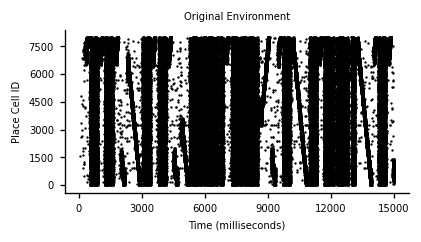

In [16]:
path = "figs/raster_104125_600DPI.png"
fig, ax = plot_pc_raster_professional(expid=104125, marker_size=2.0, figsize=(3.5,2.0), engine=engine, hz_min=10, color_by_bin=False, alpha=1.0, outpath=path, legend_position="top_right", chart_title="Original Environment",xlabel="Time (milliseconds)", ylabel="Place Cell ID")

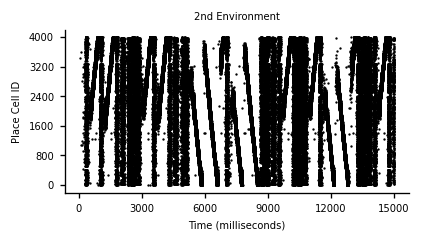

In [18]:
path = "figs/raster_104125_PC_Order_600DPI.png"
fig, ax = plot_pc_raster_professional(expid=104125, use_pc_order=True,marker_size=2.0, figsize=(3.5,2.0), engine=engine, hz_min=10, color_by_bin=False, alpha=1.0, outpath=path, legend_position="top_right", chart_title="2nd Environment",xlabel="Time (milliseconds)", ylabel="Place Cell ID")